#WINE QUALITY PREDICTION

In [2]:
import pandas as pd

df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## Dataset Overview

The dataset contains 1,143 wine samples with 11 chemical properties used to predict wine quality.

The target variable is quality, which represents the overall quality score assigned to the wine.

##Remove Unnecessary Column

Identifier (ID) is a unique value used only to distinguish records. It does not help the model learn patterns.

In [4]:
df.drop("Id", axis=1, inplace=True)

In [5]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


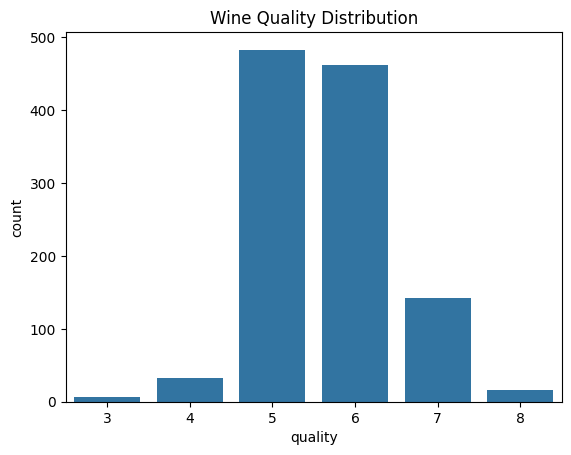

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='quality', data=df)

plt.title("Wine Quality Distribution")
plt.show()

Class Distribution shows how many samples belong to each quality category.

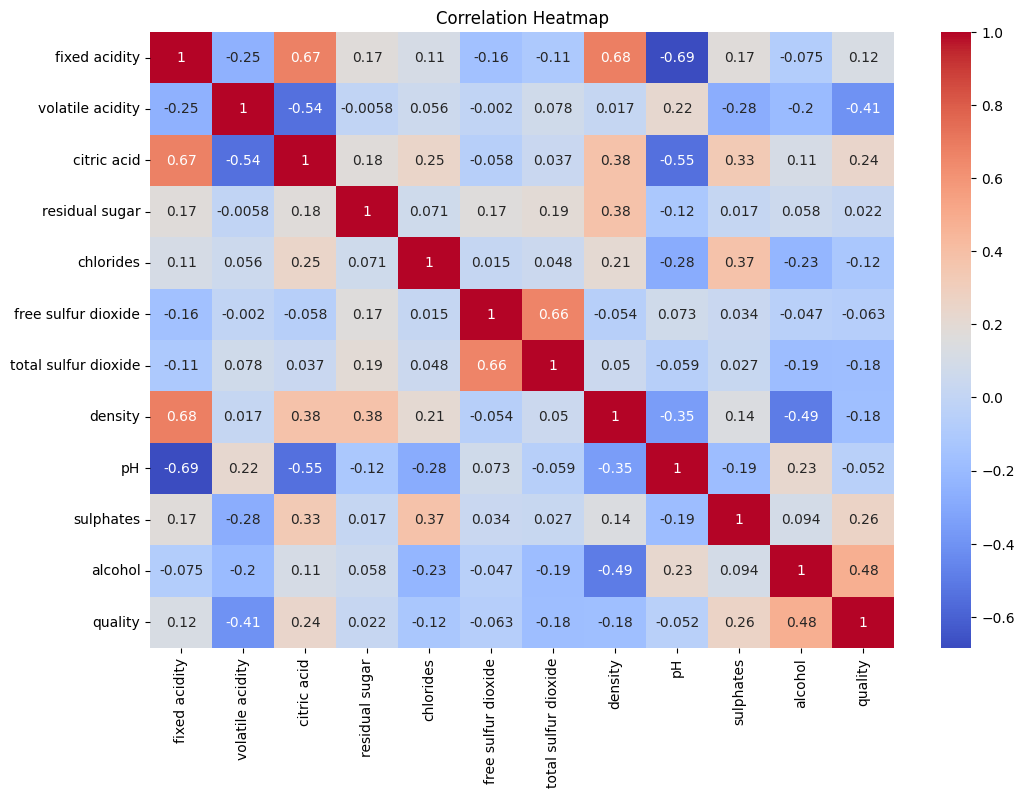

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

###Convert to Binary Classification

Wine quality values are:

3,4,5,6,7,8

Let's define:

Quality ≥ 7 → Good Wine (1)

Quality < 7 → Bad Wine (0)

In [8]:
df['quality'] = df['quality'].apply(
    lambda x: 1 if x >= 7 else 0
)

In [9]:
X = df.drop("quality", axis=1)

y = df["quality"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

LETS  ANALYZE THE QUALITY USING 3 DIFFERENT CLASSIFIERS
1. RANDOM FOREST
2. SGD
3. SVC

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9170305676855895


##Random Forest combines multiple decision trees and takes a majority vote.

In [12]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

sgd_accuracy = accuracy_score(
    y_test,
    sgd_pred
)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.8864628820960698


##Stochastic Gradient Descent (SGD) updates model parameters one sample at a time to improve efficiency.

In [13]:
from sklearn.svm import SVC

svc = SVC()

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

svc_accuracy = accuracy_score(
    y_test,
    svc_pred
)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.8820960698689956


##Support Vector Machine (SVM) finds the optimal boundary that separates classes.

NOW LET US COMPARE THESE THREE CLASSIFIERS RESULT

In [14]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.917031
1            SGD  0.886463
2            SVC  0.882096


In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.163982
9              sulphates    0.120266
1       volatile acidity    0.112545
7                density    0.103119
2            citric acid    0.086050
0          fixed acidity    0.077569
4              chlorides    0.073959
6   total sulfur dioxide    0.072437
8                     pH    0.067294
3         residual sugar    0.065264
5    free sulfur dioxide    0.057516


PREDICT QUALITY OF NEW WINE

In [19]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Good Quality Wine 🍷")
else:
    print("Bad Quality Wine 🍷")

Bad Quality Wine 🍷


## Key Insights

- Alcohol content is one of the strongest indicators of wine quality.
- Higher volatile acidity often reduces wine quality.
- Sulphates contribute positively to wine quality.
- Density and citric acid influence classification performance.
- Random Forest generally achieves the highest accuracy among the evaluated models.
- Machine learning can effectively predict wine quality using chemical properties.